In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


# Week-3

**Note to Learners**:

- For questions that involve plotting, just enter $0$ as the answer in the portal.
- For numerical questions, there are two parts. The first part expects you to compute some quantity, say a parameter of a machine learning model. The second part will require you to convert this quantity (if it is not a scalar) into a scalar so that it can be entered as the answer on the portal to the corresponding NAT question.



## Dataset

Run the cell given below to generate the data-matrix $\mathbf{X}$, which is of shape $(n, d)$, where $n$ denotes the number of samples and $d$ denotes the number of features. You will be using this dataset for the rest of the assignment.

**Do not edit this cell.**

In [ ]:
np.random.seed(0)

N = 2000
data1 = np.random.randn(N//3,2) + np.array([2,2])
data2 = np.random.randn(N//3,2) + np.array([-3,-3])
data3 = np.random.randn(N//3,2) + np.array([-5,3])
X = np.concatenate((data1, data2, data3))


## Problem 1
How many samples are there in the dataset?



## Solution

In [ ]:
# Enter your solution here
X.shape[0]

1998

## Problem 2

How many features are there in the dataset?


## Solution

In [ ]:
# Enter your solution here
X.shape[1]

2

## Problem 3
Plot the dataset using matplotlib.



## Solution

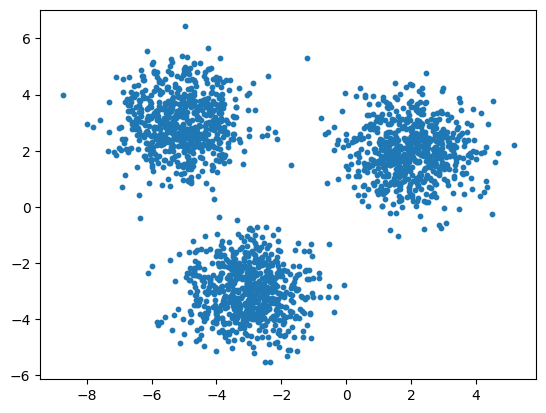

In [ ]:
# Enter your solution here
plt.scatter(X[:,0],X[:,1],marker="o",s=10)
plt.show()

## Instruction

Assume k = 3. Take the data points with indices 200, 800 and 1200 in X to be the initial cluster centers.


In [ ]:
# Enter your code here
u1 = X[200]
u2 = X[800]
u3 = X[1200]
clusters = np.array([u1,u2,u3])
clusters # 3X2

array([[ 1.40134606,  0.88410301],
       [-2.56922887, -3.14989159],
       [-2.84782302, -3.37412632]])

## Problem 4

Write a function `assign_clusters(X, k, cluster_centers)` that assigns a cluster to each data point as per their distance from each cluster centre and returns a vector `z`, where $z[i] \in \{0, 1, 2\}$.

What is the mean of the values in vector `z`? Provide the answer correct up to three decimal places.



## Solution

In [ ]:
# Enter your solution here
def assign_clusters(X,k,cluster_centers):
  z = np.full(X.shape[0],-1)
  for i in range(X.shape[0]):
    temp = []
    for j in range(k):
      temp.append(np.sum((X[i]-cluster_centers[j])**2))
    z[i] = np.argmin(temp)
  return z


z = assign_clusters(X,3,clusters)
z.mean()

np.float64(0.7107107107107107)

## Problem 5

Plot the data points, with different color for different clusters.


## Solution

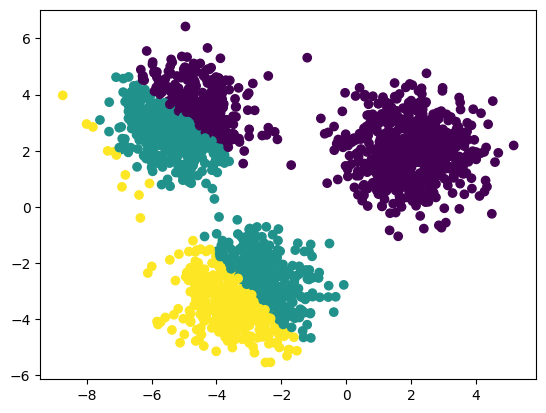

In [ ]:
# Enter your solution here
plt.scatter(X[:,0],X[:,1],c=z)

## Problem 6
Write a function `compute_cluster_centers(X, z, k)` that computes the clusters' centers as per z and returns `k` new cluster centers.

What is the mean of the three cluster centers? Provide the $x_1$ and $y_1$ component. Provide both components correct up to three decimal places.



## Solution

In [ ]:
# Enter your solution here

def compute_cluster_centers(X,z,k):
  centers = np.zeros((k, X.shape[1])) # (3X2)

  for i in range(k):
      centers[i] = X[z == i].mean(axis=0)
      # print(i,centers[i],end = "\n\n")
      # print(X[z==i].mean(axis=0))
      # print(X[z==i].shape)

  return centers



# compute_cluster_centers(X,z,3).mean(axis=0)
val = compute_cluster_centers(X,z,3)
print(val)


[[ 0.15243752  2.47002787]
 [-4.09339723  0.26891354]
 [-3.71658966 -3.31569723]]


## Extra

Keep executing the code in problems 4, 5 and 6 (for, say, 10 iterations) to observe how the clusters change across different iterations.

## Solution

In [ ]:
u1 = X[200]
u2 = X[800]
u3 = X[1200]
clusters = np.array([u1,u2,u3])
K = 3

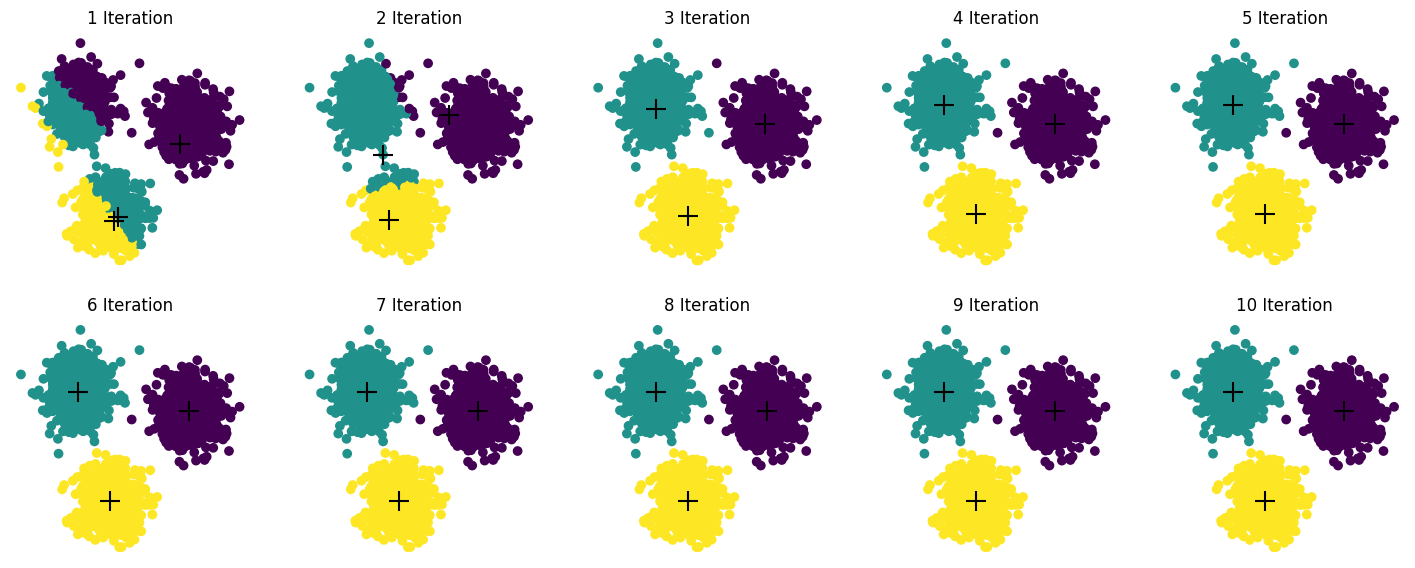

In [ ]:
# Enter your code here

# for i in range(10):
#   z = assign_clusters(X,K,clusters)
#   plt.scatter(X[:,0],X[:,1],c=z)
#   plt.scatter(clusters[:,0],clusters[:,1],marker="+",s=200,color="k")
#   clusters = compute_cluster_centers(X,z,K)
#   plt.show()

from matplotlib.lines import Line2D

fig = plt.figure(figsize=(18,18))
for i in range(10):
  z = assign_clusters(X,K,clusters)

  ax1 = fig.add_subplot(5,5,i+1)
  ax1.scatter(X[:,0],X[:,1],c=z)
  ax1.scatter(clusters[:,0],clusters[:,1],marker="+",s=200,color="k")
  ax1.set_title(f"{i+1} Iteration")
  # ax1.axhline(y=0)
  ax1.set_axis_off()
  clusters = compute_cluster_centers(X,z,K)


plt.show()



